# Stock Market Analysis: Tesla, Ford & GM

Analysis of historical stock data for Tesla, Ford, and General Motors (2012–2017), comparing price trends, trading volume, moving averages, and risk-return profiles.

**Tools:** Python, pandas, NumPy, Matplotlib

## What this analysis covers
- Price and trading volume trends across the three companies
- 50-day and 200-day moving averages
- Daily returns and volatility comparison
- Cumulative returns — growth of $1 invested in each stock
- Correlation between the three stocks' daily returns

## Key finding
Tesla showed the highest cumulative return but also the widest daily return distribution, indicating higher volatility.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
import pandas_datareader
import datetime

In [7]:
import pandas_datareader.data as web

In [8]:
start = datetime.datetime(2012,1,1)
end = datetime.datetime(2017,1,1)

In [9]:
tesla = pd.read_csv('Tesla_Stock.csv',index_col='Date',parse_dates=True)
ford = pd.read_csv('Ford_Stock.csv',index_col='Date',parse_dates=True)
gm = pd.read_csv('GM_Stock.csv',index_col='Date',parse_dates=True)

In [14]:
ford.head()

,Open,High,Low,Close,Volume
Date,,,,,
2012-01-03,11.00,11.25,10.99,11.13,45709811
2012-01-04,11.15,11.53,11.07,11.30,79725188
2012-01-05,11.33,11.63,11.24,11.59,67877467
2012-01-06,11.74,11.80,11.52,11.71,59840605
2012-01-09,11.83,11.95,11.70,11.80,53981467


In [15]:
gm.head()

,Open,High,Low,Close,Volume
Date,,,,,
2012-01-03,20.83,21.18,20.75,21.05,9321420
2012-01-04,21.05,21.37,20.75,21.15,7856752
2012-01-05,21.10,22.29,20.96,22.17,17884040
2012-01-06,22.26,23.03,22.24,22.92,18234608
2012-01-09,23.20,23.43,22.70,22.84,12091714


In [10]:
tesla.head()

,Open,High,Low,Close,Volume
Date,,,,,
2012-01-03,28.94,29.50,27.65,28.08,928052
2012-01-04,28.21,28.67,27.50,27.71,630036
2012-01-05,27.76,27.93,26.85,27.12,1005432
2012-01-06,27.20,27.79,26.41,26.89,687081
2012-01-09,27.00,27.49,26.12,27.25,896951


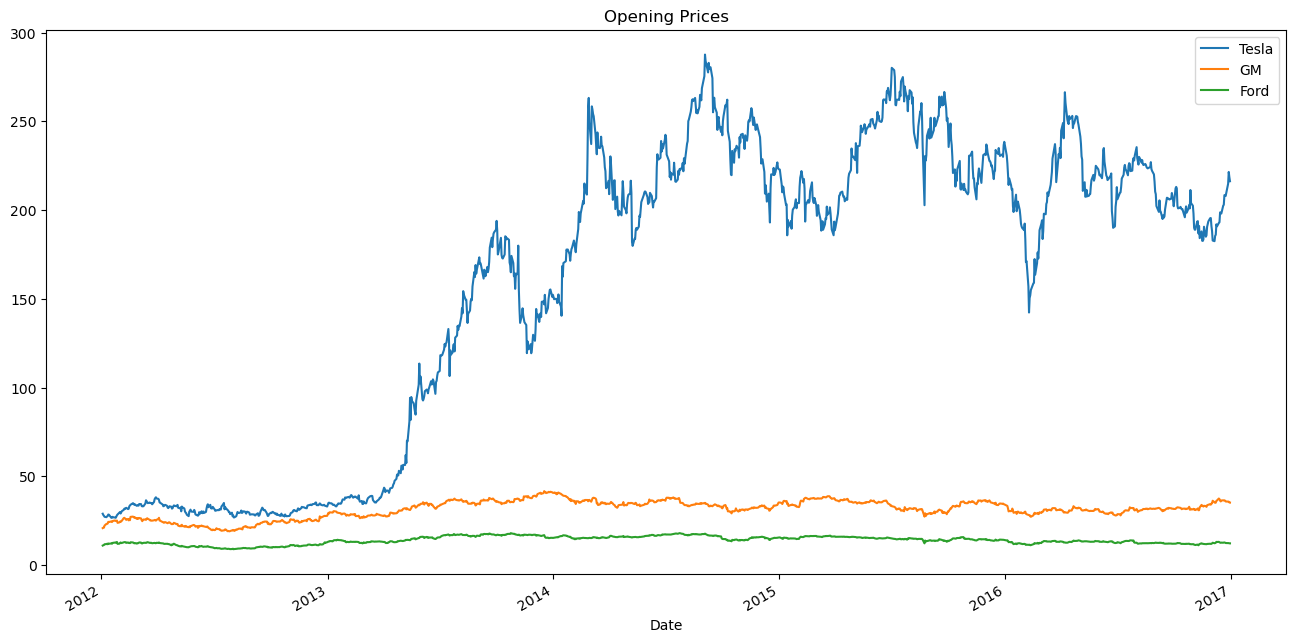

In [11]:
# Creating linear plot of all three stock's opening prices

tesla['Open'].plot(label='Tesla',figsize=(16,8),title='Opening Prices')
gm['Open'].plot(label='GM')
ford['Open'].plot(label='Ford')
plt.legend();

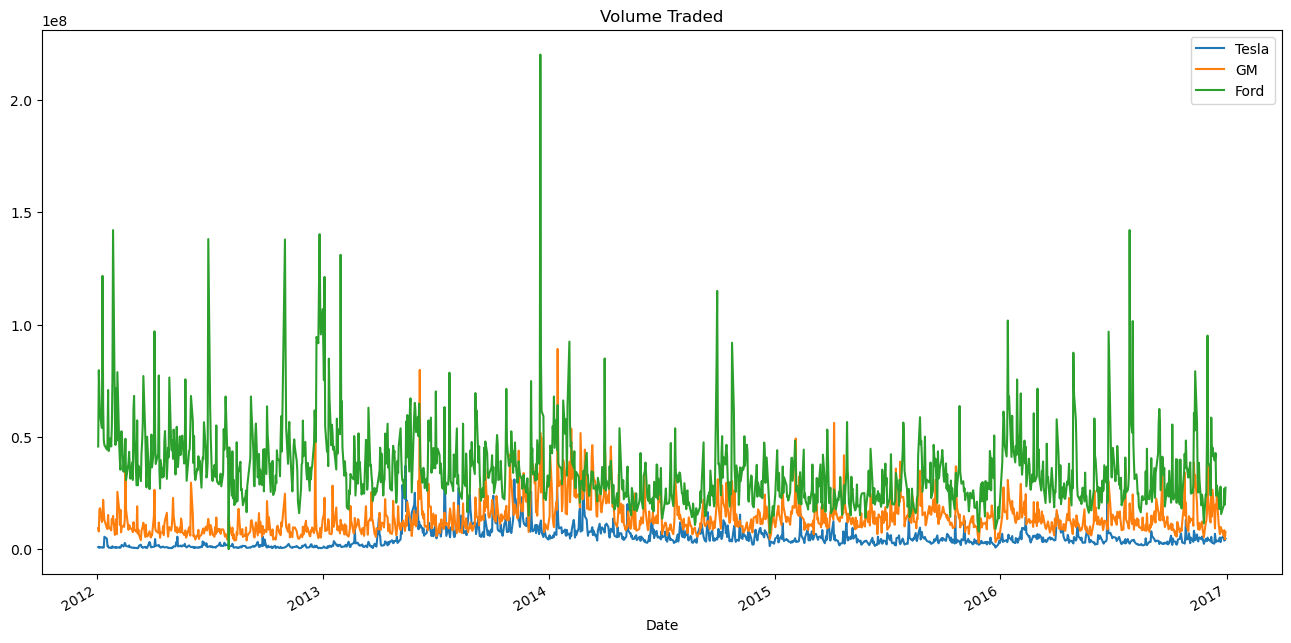

In [13]:
# Plotted Volume of all three stocks traded each day

tesla['Volume'].plot(label='Tesla',figsize=(16,8),title='Volume Traded')
gm['Volume'].plot(label='GM')
ford['Volume'].plot(label='Ford')
plt.legend();

In [14]:
# Finding the date of the maximum traded volume of Ford

ford['Volume'].idxmax()

Timestamp('2013-12-18 00:00:00')

In [15]:
# Creating new column to visualize the total amount of money being traded around using time series data
 
tesla['Total Traded'] = tesla['Open']*tesla['Volume']
gm['Total Traded'] = gm['Open']*gm['Volume']
ford['Total Traded'] = ford['Open']*ford['Volume']

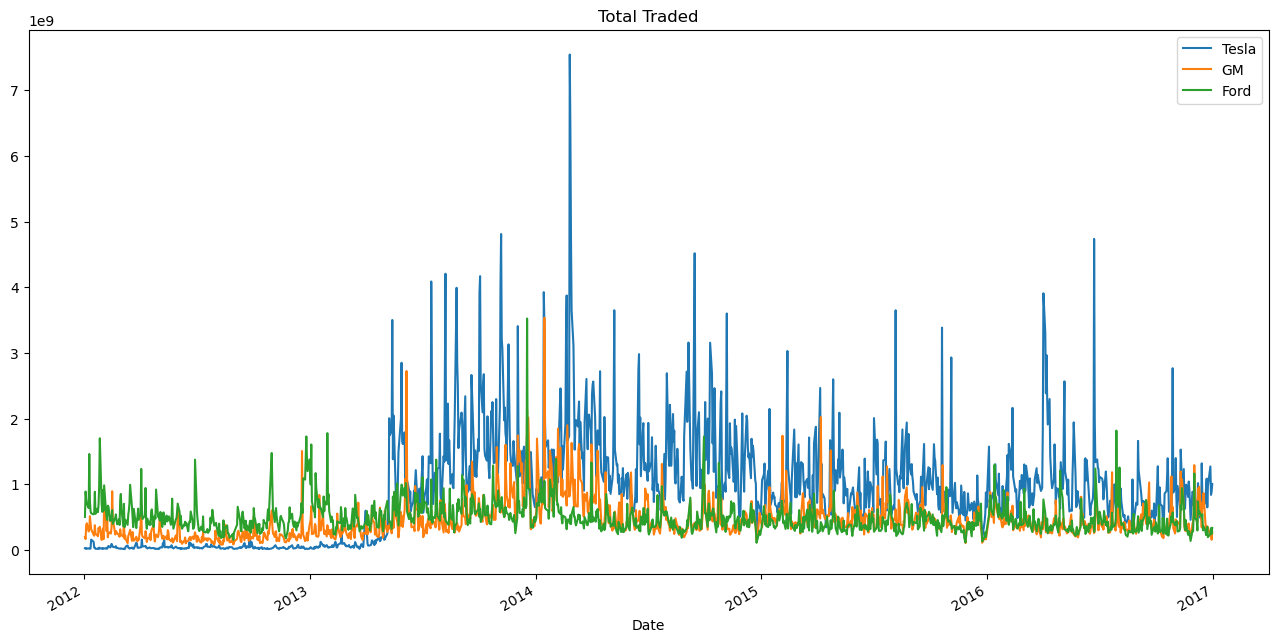

In [16]:
tesla['Total Traded'].plot(label='Tesla',figsize=(16,8),title='Total Traded')
gm['Total Traded'].plot(label='GM')
ford['Total Traded'].plot(label='Ford')
plt.legend();

In [48]:
# Finding the date of the highest amount traded being Tesla

tesla['Total Traded'].idxmax()

Timestamp('2014-02-25 00:00:00')

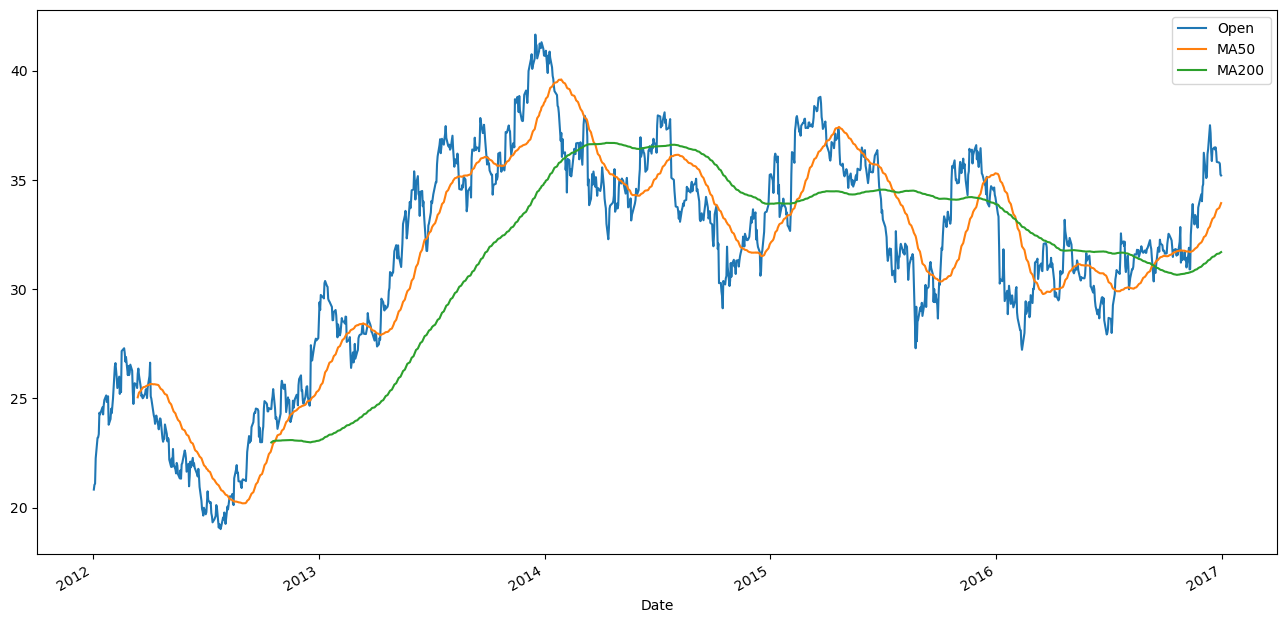

In [19]:
# Plotting out the moving averages for all stocks

gm['MA50'] = gm['Open'].rolling(50).mean()
gm['MA200'] = gm['Open'].rolling(200).mean()
gm[['Open','MA50','MA200']].plot(figsize=(16,8))
plt.legend();

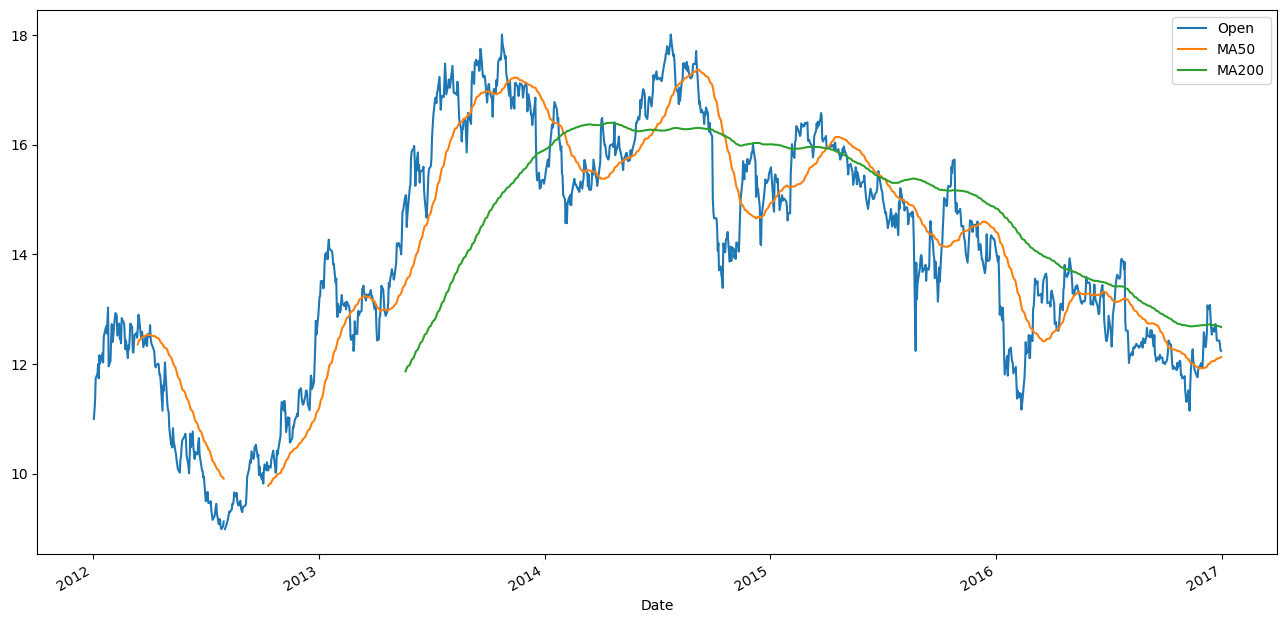

In [20]:
ford['MA50'] = ford['Open'].rolling(50).mean()
ford['MA200'] = ford['Open'].rolling(200).mean()
ford[['Open','MA50','MA200']].plot(figsize=(16,8))
plt.legend();

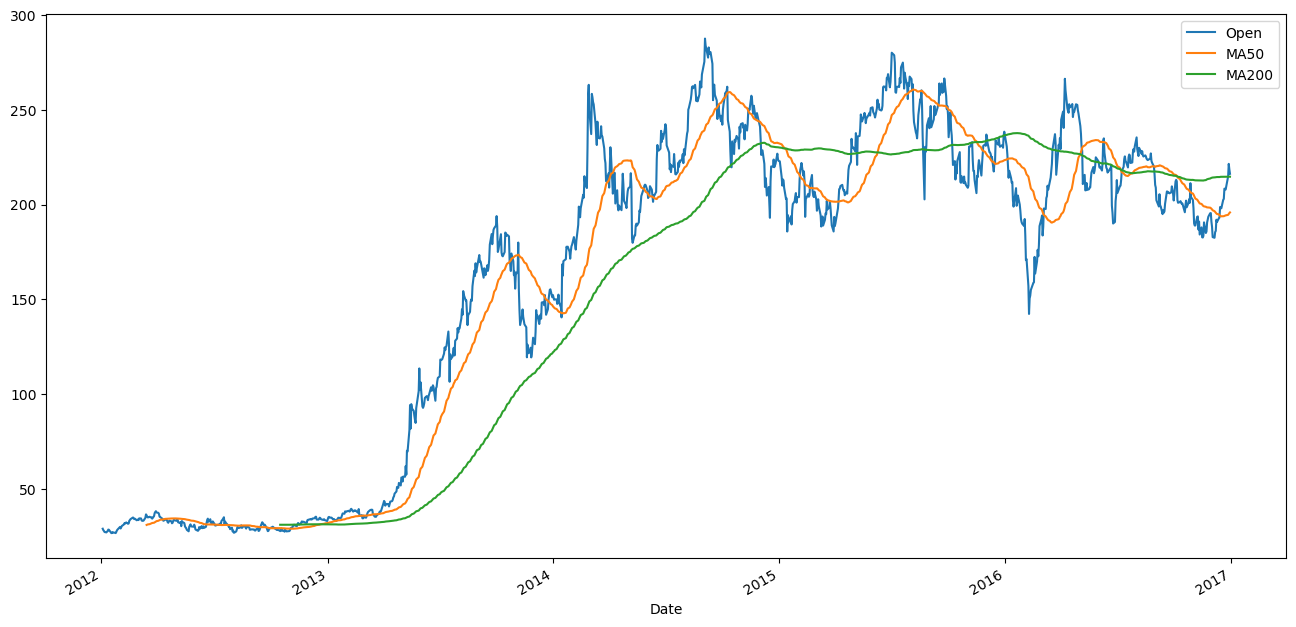

In [21]:
tesla['MA50'] = tesla['Open'].rolling(50).mean()
tesla['MA200'] = tesla['Open'].rolling(200).mean()
tesla[['Open','MA50','MA200']].plot(figsize=(16,8))
plt.legend();

In [22]:
# Now we are analyzing the relationship being these three stocks in relation to the car industry by utilizing a scatter matrix plot.

from pandas.plotting import scatter_matrix

In [23]:
car_comp = pd.concat([tesla['Open'],gm['Open'],ford['Open']],axis=1)

In [24]:
car_comp.columns = ['Tesla Open', 'GM Open', 'Ford Open']

In [25]:
car_comp.head()

,Tesla Open,GM Open,Ford Open
Date,,,
2012-01-03,28.94,20.83,11.00
2012-01-04,28.21,21.05,11.15
2012-01-05,27.76,21.10,11.33
2012-01-06,27.20,22.26,11.74
2012-01-09,27.00,23.20,11.83


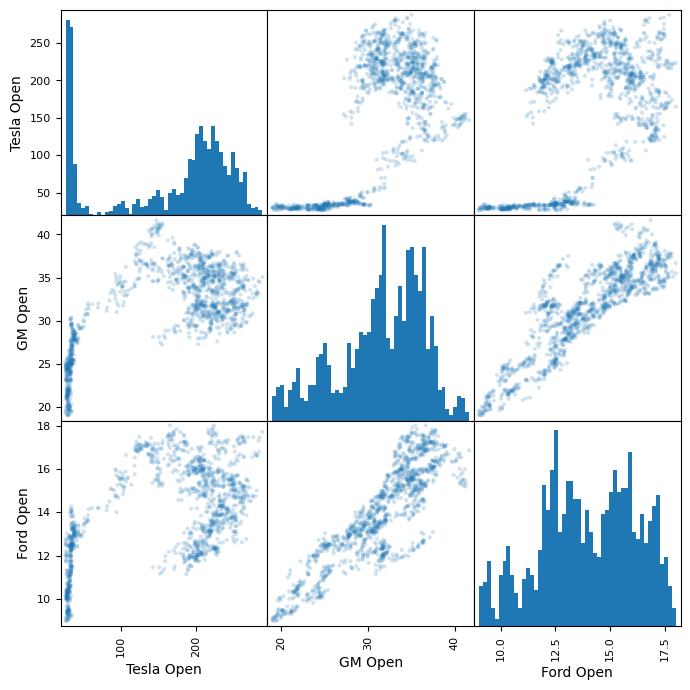

In [26]:
scatter_matrix(car_comp,figsize=(8,8),alpha=0.2,hist_kwds={'bins':50});

In [27]:
# Calculation of the Daily Percentage Change of all three stocks

tesla['returns'] = (tesla['Close'] / tesla['Close'].shift(1)) - 1

In [28]:
tesla['returns'] = tesla['Close'].pct_change(1)
ford['returns'] = ford['Close'].pct_change(1)
gm['returns'] = gm['Close'].pct_change(1)

In [29]:
ford.head()

,Open,High,Low,Close,Volume,Total Traded,MA50,MA200,returns
Date,,,,,,,,,
2012-01-03,11.00,11.25,10.99,11.13,45709811,5.028079e+08,NaN,NaN,NaN
2012-01-04,11.15,11.53,11.07,11.30,79725188,8.889358e+08,NaN,NaN,0.015274
2012-01-05,11.33,11.63,11.24,11.59,67877467,7.690517e+08,NaN,NaN,0.025664
2012-01-06,11.74,11.80,11.52,11.71,59840605,7.025287e+08,NaN,NaN,0.010354
2012-01-09,11.83,11.95,11.70,11.80,53981467,6.386008e+08,NaN,NaN,0.007686


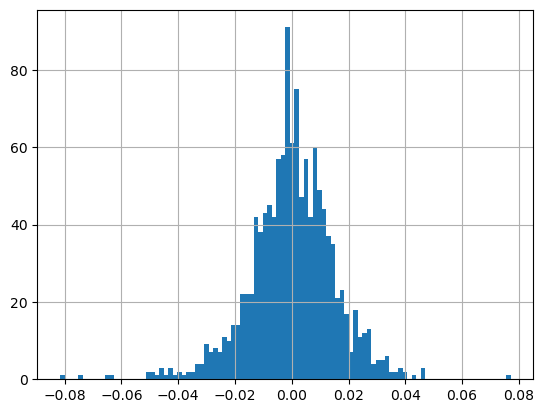

In [30]:
# We utilize a Histogram plot to explain which stock is more volatile

ford['returns'].hist(bins=100);

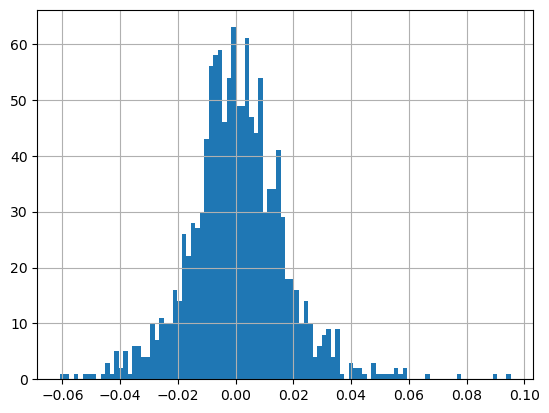

In [31]:
gm['returns'].hist(bins=100);

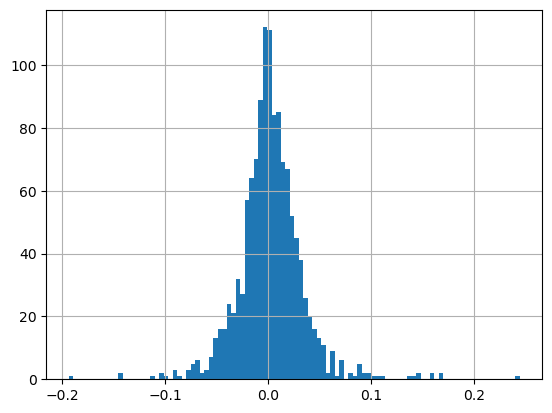

In [32]:
tesla['returns'].hist(bins=100);

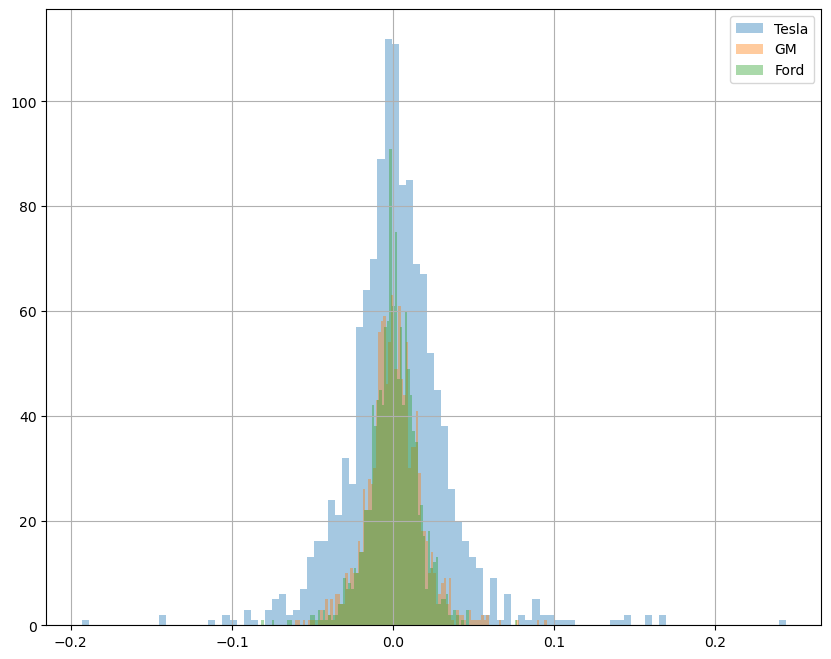

In [33]:
# By stacking all three histograms we can see thatTesla has a lot more volatility and has less stablility than GM and Ford. 

tesla['returns'].hist(bins=100,label='Tesla',figsize=(10,8),alpha=0.4)
gm['returns'].hist(bins=100,label='GM',alpha=0.4)
ford['returns'].hist(bins=100,label='Ford',alpha=0.4)
plt.legend();

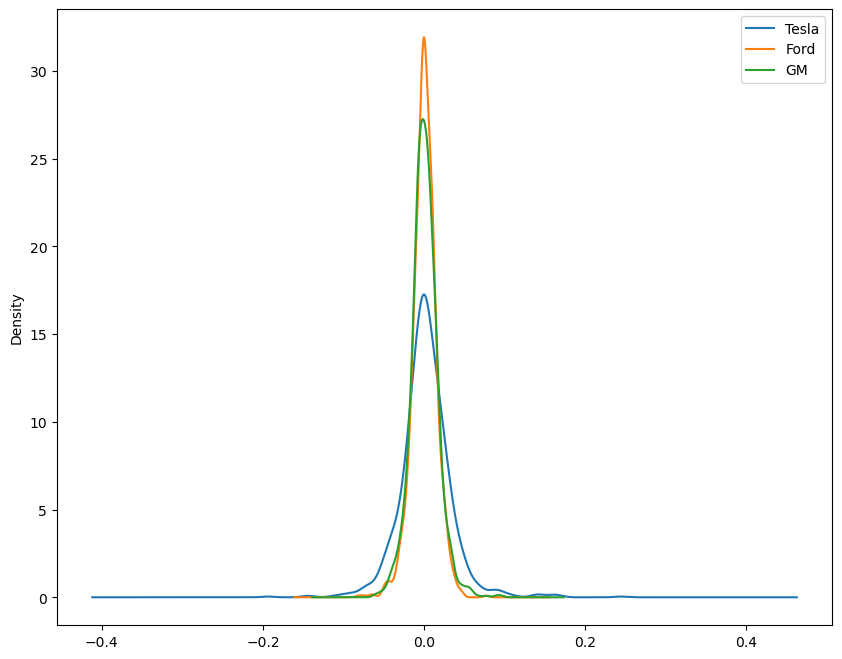

In [34]:
# Using a Kernal Density Estimation, another method, we can see Ford has the highest peak centered around zero, 
# the stock is more stable, Tesla being more wide indicates more voilatility

tesla['returns'].plot(kind='kde',label='Tesla',figsize=(10,8))
ford['returns'].plot(kind='kde',label='Ford',figsize=(10,8))
gm['returns'].plot(kind='kde',label='GM',figsize=(10,8))
plt.legend();

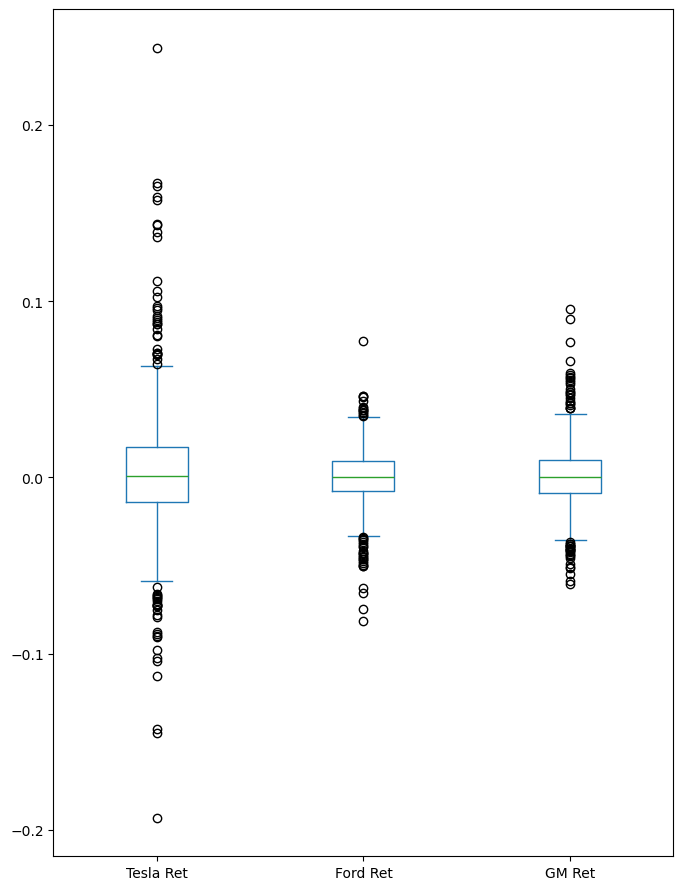

In [41]:
# Comparison of returns utilizing box plots with pandas

box_df = pd.concat([tesla['returns'],ford['returns'],gm['returns']],axis=1)
box_df.columns = ['Tesla Ret','Ford Ret','GM Ret']
box_df.plot(kind='box',figsize=(8,11));

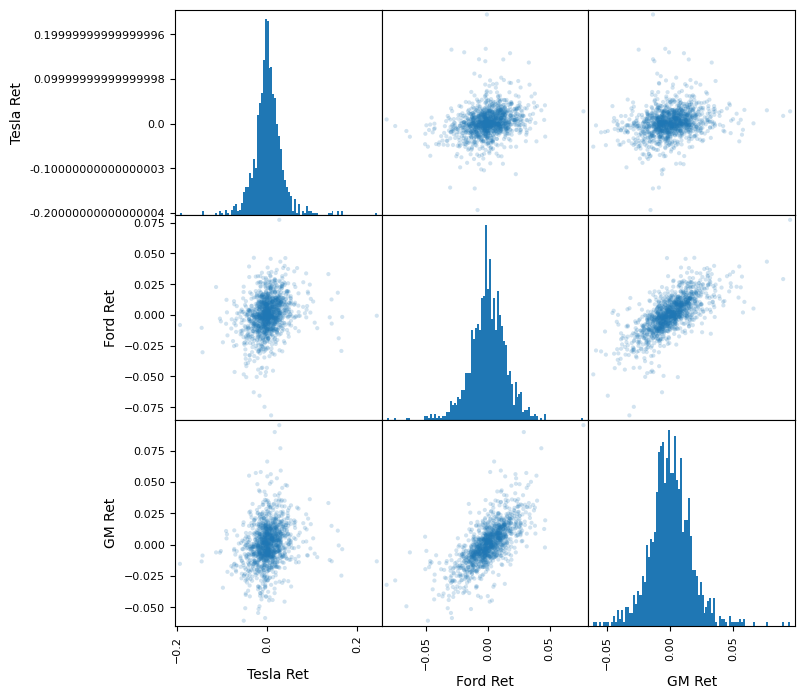

In [46]:
# Now we use a scatter matrix to see the correlation between each of the stocks daily returns

scatter_matrix(box_df,figsize=(8,8),alpha=0.2,hist_kwds={'bins':100});

** It looks like Ford and GM do have some sort of possible relationship, let's plot just these two against eachother in scatter plot to view this more closely!**

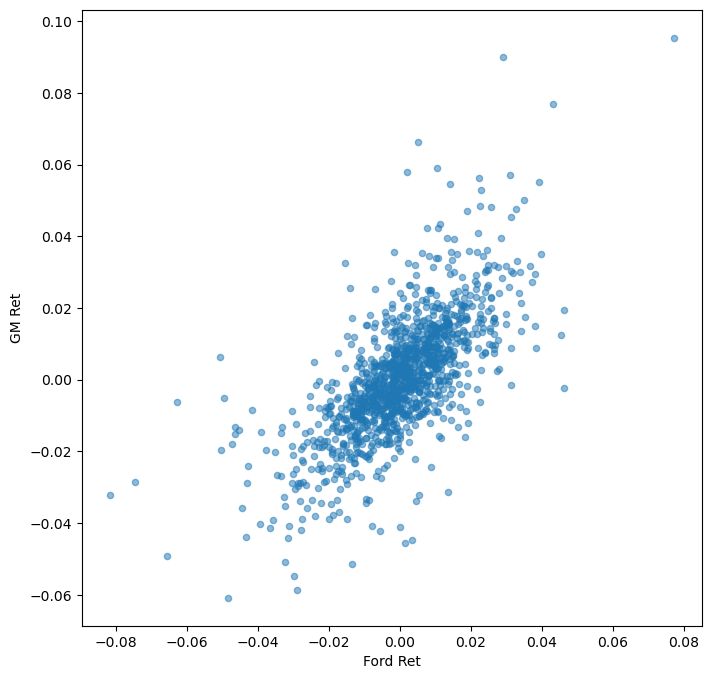

In [48]:
# We can see that Ford and GM have a possible relationship, so we utilize a scatter plot to view this more closely

box_df.plot(kind='scatter',x='Ford Ret',y='GM Ret',alpha=0.5,figsize=(8,8));

In [34]:
# Now we will try to find the cumulative daily returns, if $1 is invested in any of these companies how much would it be worth today 
# (not accounting for dividends)

tesla['Cumulative Return'] = (1 + tesla['returns']).cumprod()
ford['Cumulative Return'] = (1 + ford['returns']).cumprod()
gm['Cumulative Return'] = (1 + gm['returns']).cumprod()

In [55]:
ford

,Open,High,Low,Close,Volume,returns,Cumulative Return
Date,,,,,,,
2012-01-03,11.00,11.25,10.99,11.13,45709811,NaN,NaN
2012-01-04,11.15,11.53,11.07,11.30,79725188,0.015274,1.015274
2012-01-05,11.33,11.63,11.24,11.59,67877467,0.025664,1.041330
2012-01-06,11.74,11.80,11.52,11.71,59840605,0.010354,1.052111
2012-01-09,11.83,11.95,11.70,11.80,53981467,0.007686,1.060198
...,...,...,...,...,...,...,...
2016-12-23,12.43,12.46,12.36,12.46,15621178,0.004839,1.119497
2016-12-27,12.43,12.51,12.36,12.39,19467440,-0.005618,1.113208
2016-12-28,12.37,12.45,12.22,12.25,26875381,-0.011299,1.100629


In [35]:
gm

,Open,High,Low,Close,Volume,Total Traded,MA50,MA200,returns,Cumulative Return
Date,,,,,,,,,,
2012-01-03,20.83,21.18,20.75,21.05,9321420,1.941652e+08,NaN,NaN,NaN,NaN
2012-01-04,21.05,21.37,20.75,21.15,7856752,1.653846e+08,NaN,NaN,0.004751,1.004751
2012-01-05,21.10,22.29,20.96,22.17,17884040,3.773532e+08,NaN,NaN,0.048227,1.053207
2012-01-06,22.26,23.03,22.24,22.92,18234608,4.059024e+08,NaN,NaN,0.033829,1.088836
2012-01-09,23.20,23.43,22.70,22.84,12091714,2.805278e+08,NaN,NaN,-0.003490,1.085036
...,...,...,...,...,...,...,...,...,...,...
2016-12-23,35.83,35.87,35.54,35.69,9351152,3.350518e+08,33.6438,31.61535,0.000000,1.695487
2016-12-27,35.80,35.93,35.50,35.54,6008707,2.151117e+08,33.7246,31.63845,-0.004203,1.688361
2016-12-28,35.74,35.80,35.13,35.15,8451852,3.020692e+08,33.8026,31.66285,-0.010974,1.669834


In [36]:
tesla

,Open,High,Low,Close,Volume,Total Traded,MA50,MA200,returns,Cumulative Return
Date,,,,,,,,,,
2012-01-03,28.94,29.50,27.65,28.08,928052,2.685782e+07,NaN,NaN,NaN,NaN
2012-01-04,28.21,28.67,27.50,27.71,630036,1.777332e+07,NaN,NaN,-0.013177,0.986823
2012-01-05,27.76,27.93,26.85,27.12,1005432,2.791079e+07,NaN,NaN,-0.021292,0.965812
2012-01-06,27.20,27.79,26.41,26.89,687081,1.868860e+07,NaN,NaN,-0.008481,0.957621
2012-01-09,27.00,27.49,26.12,27.25,896951,2.421768e+07,NaN,NaN,0.013388,0.970442
...,...,...,...,...,...,...,...,...,...,...
2016-12-23,208.00,213.45,207.71,213.34,4670464,9.714565e+08,194.3384,214.73520,0.023459,7.597578
2016-12-27,214.88,222.25,214.42,219.53,5915732,1.271172e+09,194.6228,214.74635,0.029015,7.818020
2016-12-28,221.53,223.80,217.20,219.74,3782456,8.379275e+08,195.1124,214.78265,0.000957,7.825499


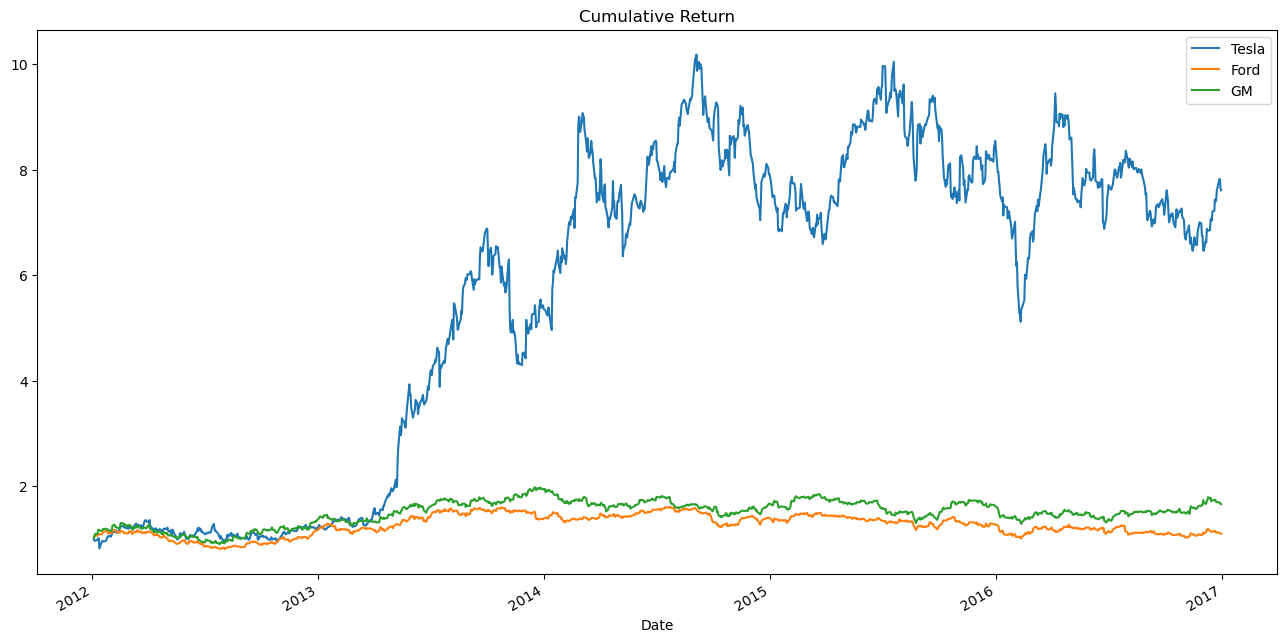

In [57]:
# We can see that tesla had the largest cumulative returns. Ford had the lowest cumulative returns 
# (assuming a $1 invested)

tesla['Cumulative Return'].plot(label='Tesla',figsize=(16,8),title='Cumulative Return')
ford['Cumulative Return'].plot(label='Ford')
gm['Cumulative Return'].plot(label='GM')
plt.legend();

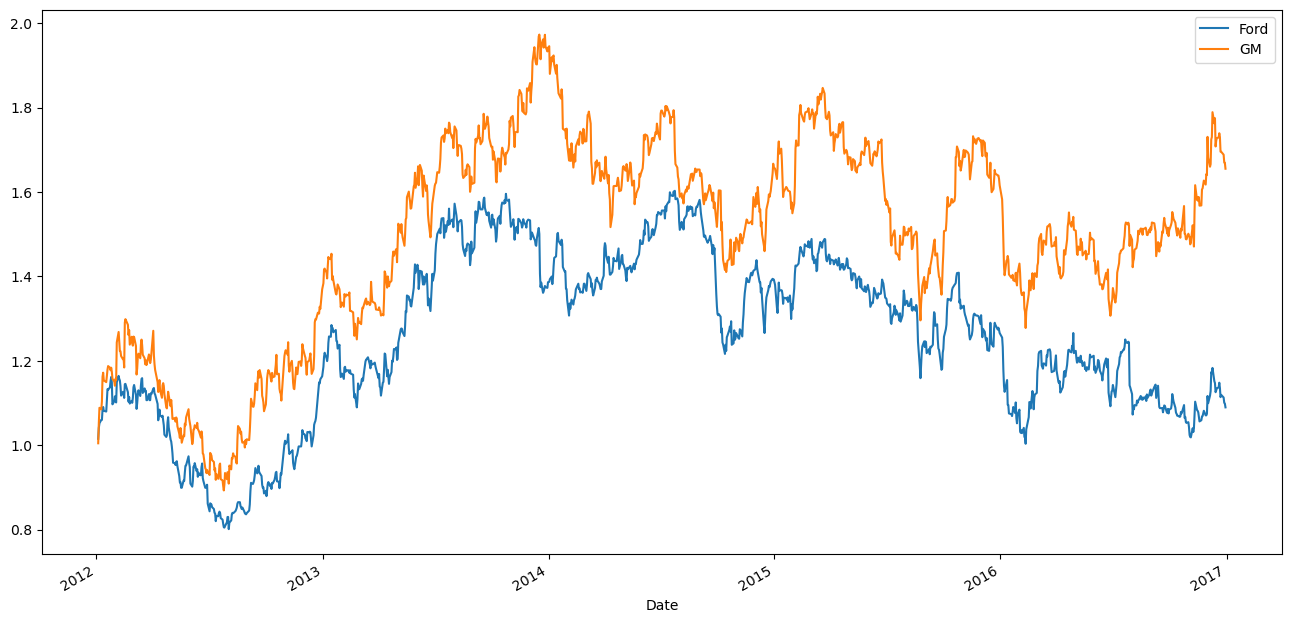

In [61]:
# By removing Tesla we can see a deeper analysis on both Ford and GM's cumulative returns 

ford['Cumulative Return'].plot(label='Ford',figsize=(16,8))
gm['Cumulative Return'].plot(label='GM')
plt.legend();